<a href="https://colab.research.google.com/github/aliyyna/Portofolio/blob/main/E_commerce_Orders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import pandas as pd
import numpy as np

## Data Preparation

In [ ]:
# load dataset
df = pd.read_csv('ecommerce_orders.csv')
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,City,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Tax_Amount,Order_Amount,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Dubai,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,2.91,68.20,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,London,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,4.91,38.73,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Berlin,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,16.50,153.66,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Riyadh,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,16.02,298.37,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Mumbai,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,7.60,105.75,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22551 entries, 0 to 22550
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 22551 non-null  int64  
 1   Customer_ID              22551 non-null  object 
 2   Order_Date               22551 non-null  object 
 3   Year                     22551 non-null  int64  
 4   Month                    22551 non-null  int64  
 5   Day                      22551 non-null  int64  
 6   Day_Of_Week              22551 non-null  object 
 7   Quarter                  22551 non-null  int64  
 8   Customer_Age             22551 non-null  int64  
 9   Customer_Gender          22551 non-null  object 
 10  Country                  22551 non-null  object 
 11  City                     22551 non-null  object 
 12  Customer_Segment         22551 non-null  object 
 13  Product_ID               22551 non-null  object 
 14  Product_Category      

In [ ]:
#hapus data tahun 2026 karena data tidak valid
df_filter = df[df['Year']==2026].index
df_baru = df.drop(index=df_filter)
df_baru = df_baru.drop(columns=['Tax_Amount']) #karena kolom ini tidak digunakan
print(df_baru)

       Order_ID Customer_ID  Order_Date  Year  Month  Day Day_Of_Week  \
0        615717  CUST007322  2023-01-01  2023      1    1      Sunday   
1        626919  CUST004717  2023-01-01  2023      1    1      Sunday   
2        615781  CUST004415  2023-01-01  2023      1    1      Sunday   
3        621747  CUST004114  2023-01-01  2023      1    1      Sunday   
4        625881  CUST000145  2023-01-01  2023      1    1      Sunday   
...         ...         ...         ...   ...    ...  ...         ...   
22546    622679  CUST001746  2025-12-31  2025     12   31   Wednesday   
22547    601664  CUST006838  2025-12-31  2025     12   31   Wednesday   
22548    602046  CUST008546  2025-12-31  2025     12   31   Wednesday   
22549    626197  CUST001459  2025-12-31  2025     12   31   Wednesday   
22550    610147  CUST005281  2025-12-31  2025     12   31   Wednesday   

       Quarter  Customer_Age Customer_Gender        Country     City  \
0            1            32            Male       

## Data Cleaning

In [ ]:
#cek duplikasi
df_baru.duplicated().sum()

np.int64(0)

In [ ]:
#cek missing value
cek_null = df_baru.isnull().sum()
display(cek_null)

,0
Order_ID,0
Customer_ID,0
Order_Date,0
Year,0
Month,0
Day,0
Day_Of_Week,0
Quarter,0
Customer_Age,0
Customer_Gender,0


In [ ]:
#ubah Order_Date menjadi datetime
df_baru['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [ ]:
#hapus kolom city karena tidak sesuai dengan country
df_new = df_baru.drop(columns=['City', 'Order_Amount'])

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22551 entries, 0 to 22550
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_ID                 22551 non-null  int64         
 1   Customer_ID              22551 non-null  object        
 2   Order_Date               22551 non-null  datetime64[ns]
 3   Year                     22551 non-null  int64         
 4   Month                    22551 non-null  int64         
 5   Day                      22551 non-null  int64         
 6   Day_Of_Week              22551 non-null  object        
 7   Quarter                  22551 non-null  int64         
 8   Customer_Age             22551 non-null  int64         
 9   Customer_Gender          22551 non-null  object        
 10  Country                  22551 non-null  object        
 11  Customer_Segment         22551 non-null  object        
 12  Product_ID               22551 n

In [ ]:
#menghitung ulang 'Order_Amount'

gross_amount = df_new['Unit_Price'] * df_new['Quantity']
discount_value = gross_amount * (df_new['Discount_Percent']/100)
df_new['Order_Amount'] = (gross_amount - discount_value) + df_new['Shipping_Cost']
df_new['Order_Amount'] = df['Order_Amount'].round(2)
print(f"Kolom berhasil ditambahkan")

Kolom berhasil ditambahkan


In [ ]:
pd.set_option('display.max_columns', None)
df_new.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,Country,Customer_Segment,Product_ID,Product_Category,Product_Subcategory,Brand,Unit_Price,Quantity,Discount_Percent,Discount_Amount,Coupon_Used,Shipping_Cost,Payment_Method,Device_Type,Traffic_Source,Membership_Status,Shipping_Method,Warehouse_Region,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order,Order_Amount
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,Germany,Loyal,PROD02374,Books,Comics,PrimePlus,18.44,3,10,5.53,Yes,15.50,Debit Card,Mobile,Social Media,Standard,Express,North,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No,68.20
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,France,Returning,PROD01378,Sports,Equipment,PrimePlus,46.58,1,40,18.63,Yes,5.87,Wallet,Mobile,Email,Standard,Standard,East,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No,38.73
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,India,Returning,PROD01850,Beauty,Skincare,Zenith,62.18,3,35,65.29,Yes,15.91,Cash on Delivery,Mobile,Paid Ads,Standard,Express,Central,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No,153.66
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,United States,Returning,PROD00545,Fashion,Women Clothing,FreshMart,91.06,3,0,0.00,No,9.17,Wallet,Desktop,Organic Search,Standard,Standard,South,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No,298.37
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,India,Premium,PROD01398,Beauty,Makeup,Zenith,99.44,1,15,14.92,Yes,13.63,PayPal,Mobile,Referral,Standard,Express,Central,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No,105.75


## Klasifikasi Tipe

In [ ]:
#klasifikasi data berdasarkan tipe (numerik/kategori)
numerik = df_new.select_dtypes(include='number').columns.tolist()
kategori = df_new.select_dtypes(include='object').columns.tolist()

print(f"Kolom bertipe numerik adalah {numerik}")
print(f"Kolom bertipe kategori adalah {kategori}")

Kolom bertipe numerik adalah ['Order_ID', 'Year', 'Month', 'Day', 'Quarter', 'Customer_Age', 'Unit_Price', 'Quantity', 'Discount_Percent', 'Discount_Amount', 'Shipping_Cost', 'Delivery_Days', 'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent', 'Profit_Amount', 'Order_Amount']
Kolom bertipe kategori adalah ['Customer_ID', 'Day_Of_Week', 'Customer_Gender', 'Country', 'Customer_Segment', 'Product_ID', 'Product_Category', 'Product_Subcategory', 'Brand', 'Coupon_Used', 'Payment_Method', 'Device_Type', 'Traffic_Source', 'Membership_Status', 'Shipping_Method', 'Warehouse_Region', 'Order_Status', 'Returned', 'Season', 'Holiday_Season', 'High_Value_Order']


## Feature Encoding

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

kolom_ordinal = ['Membership_Status']
hierarki_membership = [['Standard', 'Silver', 'Gold', 'Platinum']]

kolom_ohe = [
    'Country', 'Product_Category', 'Product_Subcategory',
    'Customer_Gender', 'Payment_Method', 'Warehouse_Region',
    'Season', 'Order_Status', 'Customer_Segment', 'Shipping_Method',
    'Holiday_Season', 'Traffic_Source', 'Device_Type', 'Returned',
    'Coupon_Used', 'High_Value_Order'
]

transformer = ColumnTransformer(
    transformers=[
        ('Country', OneHotEncoder(drop='first', sparse_output=False), kolom_ohe),
        ('Membership', OrdinalEncoder(categories=hierarki_membership), kolom_ordinal)
    ]
)
data_array = transformer.fit_transform(df_new)
kolom_sebelum = transformer.get_feature_names_out()
kolom_bersih = [col.split('__')[-1] for col in kolom_sebelum]

df_final_encoded = pd.DataFrame(data_array, columns=kolom_bersih)
kolom_angka_asli = ['Membership_Status', 'Customer_Age', 'Unit_Price', 'Quantity', 'Order_Amount', 'Profit_Amount', 'Delivery_Days']
kolom_biner = [col for col in df_final_encoded.columns if col not in kolom_angka_asli]
df_final_encoded[kolom_biner] = df_final_encoded[kolom_biner].astype(int)

df_final_encoded.head()

,Country_Canada,Country_France,Country_Germany,Country_India,Country_Pakistan,Country_Saudi Arabia,Country_UAE,Country_United Kingdom,Country_United States,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Groceries,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Product_Subcategory_Action Figures,Product_Subcategory_Appliances,Product_Subcategory_Bags,Product_Subcategory_Beverages,Product_Subcategory_Board Games,Product_Subcategory_Comics,Product_Subcategory_Cookware,Product_Subcategory_Dairy,Product_Subcategory_Decor,Product_Subcategory_Education,Product_Subcategory_Educational,Product_Subcategory_Equipment,Product_Subcategory_Fiction,Product_Subcategory_Fitness,Product_Subcategory_Fragrance,Product_Subcategory_Fresh Produce,Product_Subcategory_Furniture,Product_Subcategory_Haircare,Product_Subcategory_Headphones,Product_Subcategory_Laptop,Product_Subcategory_Makeup,Product_Subcategory_Men Clothing,Product_Subcategory_Mobile,Product_Subcategory_Non-Fiction,Product_Subcategory_Outdoor,Product_Subcategory_Puzzles,Product_Subcategory_Shoes,Product_Subcategory_Skincare,Product_Subcategory_Snacks,Product_Subcategory_Sportswear,Product_Subcategory_Women Clothing,Customer_Gender_Male,Customer_Gender_Other,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_PayPal,Payment_Method_Wallet,Warehouse_Region_East,Warehouse_Region_North,Warehouse_Region_South,Warehouse_Region_West,Season_Spring,Season_Summer,Season_Winter,Order_Status_Delivered,Order_Status_Processing,Order_Status_Returned,Order_Status_Shipped,Customer_Segment_New,Customer_Segment_Premium,Customer_Segment_Returning,Shipping_Method_Pickup,Shipping_Method_Same Day,Shipping_Method_Standard,Holiday_Season_Yes,Traffic_Source_Email,Traffic_Source_Organic Search,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media,Device_Type_Mobile,Device_Type_Tablet,Returned_Yes,Coupon_Used_Yes,High_Value_Order_Yes,Membership_Status
0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0.0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0.0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0.0
3,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0.0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0.0


In [ ]:
#hapus kolom yang tidak terpakai untuk analisa modeling
kolom_tidak_dipakai = [
    'Order_ID', 'Customer_ID', 'Product_ID','City', 'Order_Date', 'Brand'
]

df_model = df_final_encoded.drop(columns=kolom_tidak_dipakai, axis=1, errors='ignore')
df_model.head(10)

,Country_Canada,Country_France,Country_Germany,Country_India,Country_Pakistan,Country_Saudi Arabia,Country_UAE,Country_United Kingdom,Country_United States,Product_Category_Books,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Groceries,Product_Category_Home & Kitchen,Product_Category_Sports,Product_Category_Toys,Product_Subcategory_Action Figures,Product_Subcategory_Appliances,Product_Subcategory_Bags,Product_Subcategory_Beverages,Product_Subcategory_Board Games,Product_Subcategory_Comics,Product_Subcategory_Cookware,Product_Subcategory_Dairy,Product_Subcategory_Decor,Product_Subcategory_Education,Product_Subcategory_Educational,Product_Subcategory_Equipment,Product_Subcategory_Fiction,Product_Subcategory_Fitness,Product_Subcategory_Fragrance,Product_Subcategory_Fresh Produce,Product_Subcategory_Furniture,Product_Subcategory_Haircare,Product_Subcategory_Headphones,Product_Subcategory_Laptop,Product_Subcategory_Makeup,Product_Subcategory_Men Clothing,Product_Subcategory_Mobile,Product_Subcategory_Non-Fiction,Product_Subcategory_Outdoor,Product_Subcategory_Puzzles,Product_Subcategory_Shoes,Product_Subcategory_Skincare,Product_Subcategory_Snacks,Product_Subcategory_Sportswear,Product_Subcategory_Women Clothing,Customer_Gender_Male,Customer_Gender_Other,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_PayPal,Payment_Method_Wallet,Warehouse_Region_East,Warehouse_Region_North,Warehouse_Region_South,Warehouse_Region_West,Season_Spring,Season_Summer,Season_Winter,Order_Status_Delivered,Order_Status_Processing,Order_Status_Returned,Order_Status_Shipped,Customer_Segment_New,Customer_Segment_Premium,Customer_Segment_Returning,Shipping_Method_Pickup,Shipping_Method_Same Day,Shipping_Method_Standard,Holiday_Season_Yes,Traffic_Source_Email,Traffic_Source_Organic Search,Traffic_Source_Paid Ads,Traffic_Source_Referral,Traffic_Source_Social Media,Device_Type_Mobile,Device_Type_Tablet,Returned_Yes,Coupon_Used_Yes,High_Value_Order_Yes,Membership_Status
0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0.0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0.0
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0.0
3,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0.0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0.0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0.0
6,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,2.0
7,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,1.0
8,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0.0
9,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1.0


## Modeling

In [ ]:
# split data
from sklearn.model_selection import train_test_split

feature = df_model.drop(columns='High_Value_Order_Yes')
target = df_model[['High_Value_Order_Yes']]

feature_train, feature_test, target_train, target_test = train_test_split(feature, target, test_size=0.20, random_state=42)

In [ ]:
# konversi data ke numpy arrays
X_train = feature_train.to_numpy()
y_train = target_train.to_numpy().ravel()

X_test = feature_test.to_numpy()
y_test = target_test.to_numpy().ravel()

## Random Forest Classification

In [ ]:
# train random forest regression
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report

# Prediksi
y_train_pred = rfc.predict(feature_test)

# Menghitung akurasi
akurasi = accuracy_score(y_test, y_train_pred)
print("==================================================")
print(f" 🎯 SKOR AKURASI MODEL: {akurasi * 100:.2f}%")
print("==================================================\n")

# Menampilkan metrik precision, recall, dan f1-score
print("Classification Report:")
print(classification_report(y_test, y_train_pred))

 🎯 SKOR AKURASI MODEL: 87.98%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      3382
           1       0.84      0.64      0.73      1129

    accuracy                           0.88      4511
   macro avg       0.86      0.80      0.83      4511
weighted avg       0.88      0.88      0.87      4511



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


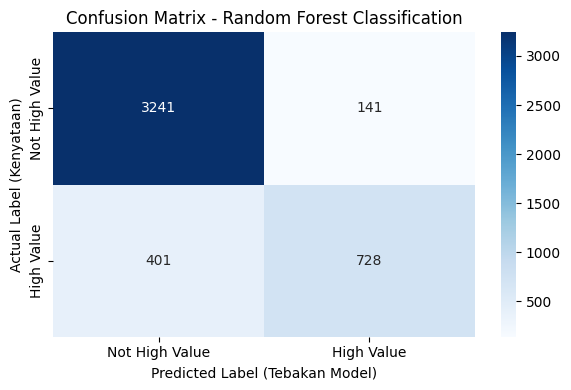

In [ ]:
# Visualisasi data confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not High Value', 'High Value'],
    yticklabels=['Not High Value', 'High Value'],
)
plt.title('Confusion Matrix - Random Forest Classification')
plt.ylabel('Actual Label (Kenyataan)')
plt.xlabel('Predicted Label (Tebakan Model)')
plt.tight_layout()
plt.show()